**This code use Arabertv02-twitter model for Women Empoerment datasets (CgatGPT-generated data, AND Falcon-generated dataset) with three main experiments:**


1.   **Experiment1**: train the model using original dataset and test it on original set
2.   **Experiment2**: train the model using synthetic dataset and test it on original set then synth set
3.   **Experiment3**: train the model using merge dataset and test it on original set




In [ ]:
!pip install torch
!pip install transformers
!pip install pandas
!pip install emoji

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 17.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.8/268.8 kB 30.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 44.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 49.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 358.9/358.9 kB 5.2 MB/s eta 0:00:00


In [ ]:
!pip install emoji==1.4.2
!pip install arabert


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.0/185.0 kB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for emoji: filename=emoji-1.4.2-py3-none-any.whl size=186456 sha256=6f82b99826a791182615c8678fd4c2b208a4b82732fe8630d75fb86b9b8d322e
  Stored in directory: /root/.cache/pip/wheels/10/f0/fd/4813b1177405693e8da9cdea839f0fb64fde161380e058c827
Successfully built emoji
  Attempting uninstall: emoji
    Found existing installation: emoji 2.8.0
    Uninstalling emoji-2.8.0:
      Successfully uninstalled emoji-2.8.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.4/126.4 kB 15.7 MB/s eta 0:00:00


In [ ]:
## Import Basics
import pandas as pd
import numpy as np
import string
import emoji
import re
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import DataLoader, Dataset
from sklearn.utils import shuffle
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AdamW
from sklearn.metrics import classification_report
from arabert.preprocess import ArabertPreprocessor
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import confusion_matrix

In [ ]:
#Select the dataset to train the model

#Experiment1:
#selected_train_dataset='Real_train_women_1190.csv' #original trainig set
#selected_test_dataset='Real_test_women_210.csv'  #original testing set

#Experiment2:
#for ChatGPT data:
#selected_train_dataset='ChatGPT_Synth_train_women_1190.csv' #ChatGPT's generated data (training set)
#selected_test_dataset='Real_test_women_210.csv'  #original testing set
#selected_ChatGPT_test_dataset='ChatGPT_Synth_test_women_210.csv'  #ChatGPT's generated data (testing set)

#Experiment3:
#for ChatGPT merge
selected_train_dataset='ChatGPT_merge_women_2380.csv'      #ChatGPT's generated data merge with original training set
selected_test_dataset='Real_test_women_210.csv'  #original testing set


For the sake of simplicity, we will present one experiment, as all other experiments follow the same steps with changes in the dataset. However, we will present the results of each experiment.

**The following presents the main steps for each experiment:**

#1. Load the datasets

In [ ]:
traindf = pd.read_csv(selected_train_dataset)

In [ ]:
testdf = pd.read_csv(selected_test_dataset)

In [ ]:
#testdf_synth= pd.read_csv(selected_ChatGPT_test_dataset) #for Experiment2 to test on synthetic data

In [ ]:
traindf= traindf[['text','stance']]

In [ ]:
traindf.head()

,text,stance
0,عشان يلمع صورته ويعنني تمكين المرأة ويصير ترن...,Against
1,هذا ما يُعرّف بـ'فوبيا المرأة المُتمكنة' آفة ف...,Favor
2,فخورين بنساء الوطن 🇸🇦 وكلنا فخر بتقدم تمكين ا...,Favor
3,ههههههههههههههه ماعليك زمن تمكين المرأة ماراح...,None
4,وين تمكين المرأة؟,None


In [ ]:
# mapping the labels
mapping = {'None': 0, 'Favor': 1, 'Against': 2}
traindf['stance'] = traindf['stance'].apply(lambda x: mapping[x])
traindf.head()

,ID,target,text,stance
0,1,Women empowerment,عشان يلمع صورته ويعنني تمكين المرأة ويصير ترن...,2
1,4,Women empowerment,هذا ما يُعرّف بـ'فوبيا المرأة المُتمكنة' آفة ف...,1
2,8,Women empowerment,فخورين بنساء الوطن 🇸🇦 وكلنا فخر بتقدم تمكين ا...,1
3,9,Women empowerment,ههههههههههههههه ماعليك زمن تمكين المرأة ماراح...,0
4,22,Women empowerment,وين تمكين المرأة؟,0


In [ ]:
testdf['stance'] = testdf['stance'].apply(lambda x: mapping[x])

In [ ]:
#testdf_synth['stance'] = testdf_synth['stance'].apply(lambda x: mapping[x]) #for exper2

#2. Visualizing the dataset

In [ ]:
traindf['stance'].value_counts()

1    1520
2     742
0     118
Name: stance, dtype: int64

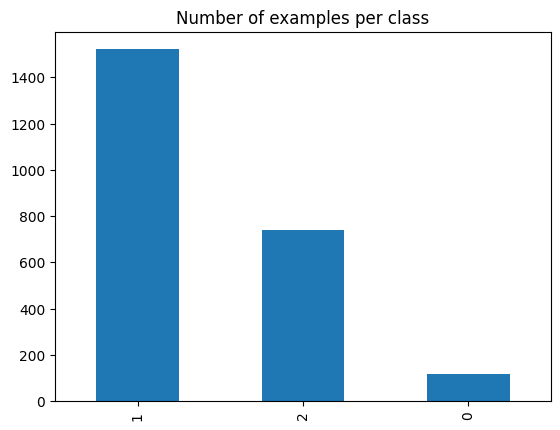

In [ ]:
traindf['stance'].value_counts().sort_values(ascending=False).plot(kind="bar")
plt.title("Number of examples per class");

In [ ]:
traindf.shape,  testdf.shape,

((2380, 2), (210, 4))

In [ ]:
 #testdf_synth.shape #(for expr2)

#3. Data Pre-processing

In [ ]:

model_name = "aubmindlab/bert-base-arabertv02-twitter"
arabert_prep = ArabertPreprocessor(model_name=model_name)


# Define a preprocessing function
def preprocess_text(text):
    return arabert_prep.preprocess(text)


In [ ]:
# apply preprocessing
traindf['text'] = traindf['text'].apply(preprocess_text)

In [ ]:
traindf.head()

,text,stance
0,عشان يلمع صورته ويعنني تمكين المرأة ويصير ترند...,2
1,هذا ما يعرف ب ' فوبيا المرأة المتمكنة ' آفة فك...,1
2,فخورين بنساء الوطن 🇸 🇦 وكلنا فخر بتقدم تمكين ا...,1
3,هه ماعليك زمن تمكين المرأة ماراح يسوون لك شي 😂,0
4,وين تمكين المرأة ؟,0


In [ ]:
traindf, val_df = train_test_split(traindf[['text', 'stance']], test_size=0.18, stratify=traindf['stance'])

In [ ]:
testdf['text'] = testdf['text'].apply(preprocess_text)

In [ ]:
#testdf_synth['text'] = testdf_synth['text'].apply(preprocess_text)

In [ ]:
traindf.shape,   testdf.shape

((1951, 2), (210, 4))

In [ ]:
val_df.shape , #synth_df.shape

In [ ]:
# creat cutom dataset to preparing tweet data for training

class Tweet_Dataset(Dataset):

  #class instance initalization (load the data)
    def __init__(self, data, tokenizer, max_length):
        self.data = data
        self.tokenizer = tokenizer
        self.max_length = max_length

    #return the length of the dataset
    def __len__(self):
        return len(self.data)

   #getting the elements
    def __getitem__(self, index):
        text = str(self.data.iloc[index]['text'])
        label = self.data.iloc[index]['stance']
        #use tokenizer object for the tweet sample
        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
       #return token IDs, attention mask for actual content, and labels
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }



#4. Train the model

In [ ]:
#load the tokenizer and the model from hugging face
tokenizer = AutoTokenizer.from_pretrained( "aubmindlab/bert-base-arabertv02-twitter")
model = AutoModelForSequenceClassification.from_pretrained( "aubmindlab/bert-base-arabertv02-twitter", num_labels=3)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at aubmindlab/bert-base-arabertv02-twitter and are newly initialized: ['classifier.bias', 'classifier.weight', 'bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
#max_length = 128  # the maximum sequence length for the tokens
training_dataset = Tweet_Dataset(traindf, tokenizer, 128)
test_dataset = Tweet_Dataset(testdf, tokenizer, 128)

In [ ]:
#setting the data loaders, device, and optimizer for training
train_loader = DataLoader(training_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
optim = AdamW(model.parameters(), lr=1e-5) #across (2e-5,1e-5, 1e-6), 1e-5 was the best
epochs = 20 # I intially train expr1 with (10,20) epochs and choose the best 10, but the val loss was increase with exp2,and exp3 then I used early stopping

/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:411: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


In [ ]:
val_dataset = Tweet_Dataset(val_df, tokenizer, 128)
val_loader = DataLoader(val_dataset, batch_size=32)


In [ ]:
#for exper2
#synth_dataset = Tweet_Dataset(testdf_synth, tokenizer, 128)
#synth_loader = DataLoader(synth_dataset, batch_size=32)


In [ ]:
# train the model
model.train()
best_valloss = float('inf')  # set best_valloss to a large value
epochs_no_improvement = 0
patience = 3

for epoch in range(epochs):
    totalloss = 0
    correctprediction = 0
    total_traindata = 0

    for batch in train_loader:
        optim.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        totalloss += loss.item()
        total_traindata += labels.size(0)

        loss.backward()
        optim.step()

        predicted_labels = outputs.logits.argmax(dim=1)
        correctprediction += (predicted_labels == labels).sum().item()#for accuracy

    average_loss = totalloss / len(train_loader)
    accuracy = correctprediction / total_traindata
    print(f'Epoch {epoch+1}/{epochs} - Average Loss: {average_loss:.4f} - Accuracy: {accuracy:.4f}')

     # Validation set
    valloss = 0
    valcorrectprediction = 0
    total_valdata = 0

    model.eval()

    with torch.no_grad():
        for val_batch in val_loader:
            val_input_ids = val_batch['input_ids'].to(device)
            val_attention_mask = val_batch['attention_mask'].to(device)
            val_labels = val_batch['labels'].to(device)

            val_outputs = model(val_input_ids, attention_mask=val_attention_mask, labels=val_labels)
            valloss += val_outputs.loss.item()
            total_valdata += val_labels.size(0)

            val_predicted_labels = val_outputs.logits.argmax(dim=1)
            valcorrectprediction += (val_predicted_labels == val_labels).sum().item()
     #calculate average val loss and accuracy
    val_average_loss = valloss / len(val_loader)
    val_accuracy = valcorrectprediction / total_valdata

    print(f'Epoch {epoch+1}/{epochs} - Train Loss: {average_loss:.4f} - Train Accuracy: {accuracy:.4f} - Val Loss: {val_average_loss:.4f} - Val Accuracy: {val_accuracy:.4f}')

    #early stopping
    if val_average_loss < best_valloss:
        best_valloss = val_average_loss
        epochs_no_improvement = 0
    else:
        epochs_no_improvement += 1

    #stop if no improvement
    if epochs_no_improvement >= patience:
        print(f'Early stopping at epoch {epoch+1}')
        break


Epoch 1/20 - Average Loss: 0.6062 - Accuracy: 0.7386
Epoch 1/20 - Train Loss: 0.6062 - Train Accuracy: 0.7386 - Val Loss: 0.3474 - Val Accuracy: 0.8765
Epoch 2/20 - Average Loss: 0.3189 - Accuracy: 0.8775
Epoch 2/20 - Train Loss: 0.3189 - Train Accuracy: 0.8775 - Val Loss: 0.2596 - Val Accuracy: 0.8928
Epoch 3/20 - Average Loss: 0.1860 - Accuracy: 0.9411
Epoch 3/20 - Train Loss: 0.1860 - Train Accuracy: 0.9411 - Val Loss: 0.2794 - Val Accuracy: 0.8974
Epoch 4/20 - Average Loss: 0.1033 - Accuracy: 0.9703
Epoch 4/20 - Train Loss: 0.1033 - Train Accuracy: 0.9703 - Val Loss: 0.2481 - Val Accuracy: 0.9138
Epoch 5/20 - Average Loss: 0.0534 - Accuracy: 0.9877
Epoch 5/20 - Train Loss: 0.0534 - Train Accuracy: 0.9877 - Val Loss: 0.2823 - Val Accuracy: 0.9091
Epoch 6/20 - Average Loss: 0.0303 - Accuracy: 0.9954
Epoch 6/20 - Train Loss: 0.0303 - Train Accuracy: 0.9954 - Val Loss: 0.2891 - Val Accuracy: 0.9091
Epoch 7/20 - Average Loss: 0.0157 - Accuracy: 0.9979
Epoch 7/20 - Train Loss: 0.0157 - T

#5. Test the model on the test set

**the following present the test results for each experiment:**

## Experemint1 results: Original data result on original test


In [ ]:
# Test the model performance that trained using the original data on the original val set

model.eval()
totalcorrect = 0
totaldata = 0
predicted_labelslist = []
true_labelslist = []
with torch.no_grad():
    for batch in val_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        predicted_labels = torch.argmax(outputs.logits, dim=1)

        totalcorrect += (predicted_labels == labels).sum().item()
        totaldata += labels.size(0)
        predicted_labelslist.extend(predicted_labels.cpu().numpy())
        true_labelslist.extend(labels.cpu().numpy())

#print results
classification_rep = classification_report(true_labelslist, predicted_labelslist)
test_confusion_matrix = confusion_matrix(true_labelslist, predicted_labelslist)
print("Classification Report:")
print(classification_rep)
print("Test Confusion Matrix:")
print(test_confusion_matrix)

Classification Report:
              precision    recall  f1-score   support

           0       0.29      0.18      0.22        11
           1       0.90      0.89      0.90       137
           2       0.74      0.81      0.77        67

    accuracy                           0.83       215
   macro avg       0.64      0.63      0.63       215
weighted avg       0.82      0.83      0.82       215

Test Confusion Matrix:
[[  2   2   7]
 [  3 122  12]
 [  2  11  54]]


In [ ]:
# Test the model performance that trained using the original data on the original test set
#new
model.eval()
totalcorrect = 0
totaldata = 0
predicted_labelslist = []
true_labelslist = []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        predicted_labels = torch.argmax(outputs.logits, dim=1)

        totalcorrect += (predicted_labels == labels).sum().item()
        totaldata += labels.size(0)
        predicted_labelslist.extend(predicted_labels.cpu().numpy())
        true_labelslist.extend(labels.cpu().numpy())

#print results
classification_rep = classification_report(true_labelslist, predicted_labelslist)
test_confusion_matrix = confusion_matrix(true_labelslist, predicted_labelslist)
print("Classification Report:")
print(classification_rep)
print("Test Confusion Matrix:")
print(test_confusion_matrix)


Classification Report:
              precision    recall  f1-score   support

           0       0.43      0.27      0.33        11
           1       0.89      0.90      0.89       134
           2       0.76      0.80      0.78        65

    accuracy                           0.83       210
   macro avg       0.69      0.66      0.67       210
weighted avg       0.83      0.83      0.83       210

Test Confusion Matrix:
[[  3   6   2]
 [  0 120  14]
 [  4   9  52]]


## Experemint2 results: Synthetic data results on original and Synthetic test sets


In [ ]:
# Test the model performance that trained using the original data on the synthetic val set

model.eval()
totalcorrect = 0
totaldata = 0
predicted_labelslist = []
true_labelslist = []
with torch.no_grad():
    for batch in val_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        predicted_labels = torch.argmax(outputs.logits, dim=1)

        totalcorrect += (predicted_labels == labels).sum().item()
        totaldata += labels.size(0)
        predicted_labelslist.extend(predicted_labels.cpu().numpy())
        true_labelslist.extend(labels.cpu().numpy())

#print results
classification_rep = classification_report(true_labelslist, predicted_labelslist)
test_confusion_matrix = confusion_matrix(true_labelslist, predicted_labelslist)
print("Classification Report:")
print(classification_rep)
print("Test Confusion Matrix:")
print(test_confusion_matrix)

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.73      0.80        11
           1       0.97      1.00      0.99       137
           2       1.00      0.97      0.98        67

    accuracy                           0.98       215
   macro avg       0.95      0.90      0.92       215
weighted avg       0.98      0.98      0.98       215

Test Confusion Matrix:
[[  8   3   0]
 [  0 137   0]
 [  1   1  65]]


In [ ]:
# Test the model performance that trained using the synthetic on the synthetic test set

model.eval()
totalcorrect = 0
totaldata = 0
predicted_labelslist = []
true_labelslist = []
with torch.no_grad():
    for batch in synth_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        predicted_labels = torch.argmax(outputs.logits, dim=1)

        totalcorrect += (predicted_labels == labels).sum().item()
        totaldata += labels.size(0)
        predicted_labelslist.extend(predicted_labels.cpu().numpy())
        true_labelslist.extend(labels.cpu().numpy())

#print results
classification_rep = classification_report(true_labelslist, predicted_labelslist)
test_confusion_matrix = confusion_matrix(true_labelslist, predicted_labelslist)
print("Classification Report:")
print(classification_rep)
print("Test Confusion Matrix:")
print(test_confusion_matrix)

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.82      0.90        11
           1       0.99      1.00      0.99       134
           2       1.00      1.00      1.00        65

    accuracy                           0.99       210
   macro avg       1.00      0.94      0.96       210
weighted avg       0.99      0.99      0.99       210

Test Confusion Matrix:
[[  9   2   0]
 [  0 134   0]
 [  0   0  65]]


In [ ]:
# Test the model performance that trained using the synthetic on the original test set

model.eval()
totalcorrect = 0
totaldata = 0
predicted_labelslist = []
true_labelslist = []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        predicted_labels = torch.argmax(outputs.logits, dim=1)

        totalcorrect += (predicted_labels == labels).sum().item()
        totaldata += labels.size(0)
        predicted_labelslist.extend(predicted_labels.cpu().numpy())
        true_labelslist.extend(labels.cpu().numpy())

#print results
classification_rep = classification_report(true_labelslist, predicted_labelslist)
test_confusion_matrix = confusion_matrix(true_labelslist, predicted_labelslist)
print("Classification Report:")
print(classification_rep)
print("Test Confusion Matrix:")
print(test_confusion_matrix)

Classification Report:
              precision    recall  f1-score   support

           0       0.15      0.18      0.17        11
           1       0.94      0.66      0.77       134
           2       0.56      0.89      0.69        65

    accuracy                           0.70       210
   macro avg       0.55      0.58      0.54       210
weighted avg       0.78      0.70      0.72       210

Test Confusion Matrix:
[[ 2  4  5]
 [ 6 88 40]
 [ 5  2 58]]


## Experemint3 results: Merge data results on original

In [ ]:
# Test the model performance that trained using the original data on the merge val set

model.eval()
totalcorrect = 0
totaldata = 0
predicted_labelslist = []
true_labelslist = []
with torch.no_grad():
    for batch in val_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        predicted_labels = torch.argmax(outputs.logits, dim=1)

        totalcorrect += (predicted_labels == labels).sum().item()
        totaldata += labels.size(0)
        predicted_labelslist.extend(predicted_labels.cpu().numpy())
        true_labelslist.extend(labels.cpu().numpy())

#print results
classification_rep = classification_report(true_labelslist, predicted_labelslist)
test_confusion_matrix = confusion_matrix(true_labelslist, predicted_labelslist)
print("Classification Report:")
print(classification_rep)
print("Test Confusion Matrix:")
print(test_confusion_matrix)

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.48      0.53        21
           1       0.94      0.94      0.94       274
           2       0.89      0.92      0.90       134

    accuracy                           0.91       429
   macro avg       0.81      0.78      0.79       429
weighted avg       0.91      0.91      0.91       429

Test Confusion Matrix:
[[ 10   7   4]
 [  6 257  11]
 [  1  10 123]]


In [ ]:
# Test the model performance that trained using the original data on the original test set

model.eval()
totalcorrect = 0
totaldata = 0
predicted_labelslist = []
true_labelslist = []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        predicted_labels = torch.argmax(outputs.logits, dim=1)

        totalcorrect += (predicted_labels == labels).sum().item()
        totaldata += labels.size(0)
        predicted_labelslist.extend(predicted_labels.cpu().numpy())
        true_labelslist.extend(labels.cpu().numpy())

#print results
classification_rep = classification_report(true_labelslist, predicted_labelslist)
test_confusion_matrix = confusion_matrix(true_labelslist, predicted_labelslist)
print("Classification Report:")
print(classification_rep)
print("Test Confusion Matrix:")
print(test_confusion_matrix)

Classification Report:
              precision    recall  f1-score   support

           0       0.22      0.18      0.20        11
           1       0.89      0.89      0.89       134
           2       0.79      0.82      0.80        65

    accuracy                           0.83       210
   macro avg       0.63      0.63      0.63       210
weighted avg       0.82      0.83      0.83       210

Test Confusion Matrix:
[[  2   7   2]
 [  3 119  12]
 [  4   8  53]]
